<a href="https://colab.research.google.com/github/michelleg-cavalari/cardioia-fase4-visao-computacional/blob/main/CardioIA_Fase4_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Instalação das bibliotecas necessárias
!pip install kagglehub

import kagglehub

# Baixar dataset Chest X-Ray Pneumonia
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Dataset baixado em:", path)

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

base_dir = os.path.join(path, "chest_xray")

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

print("Treino:", train_dir)
print("Validação:", val_dir)
print("Teste:", test_dir)

print("Classes de treino:", os.listdir(train_dir))

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset baixado em: /kaggle/input/chest-xray-pneumonia
Treino: /kaggle/input/chest-xray-pneumonia/chest_xray/train
Validação: /kaggle/input/chest-xray-pneumonia/chest_xray/val
Teste: /kaggle/input/chest-xray-pneumonia/chest_xray/test
Classes de treino: ['PNEUMONIA', 'NORMAL']


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


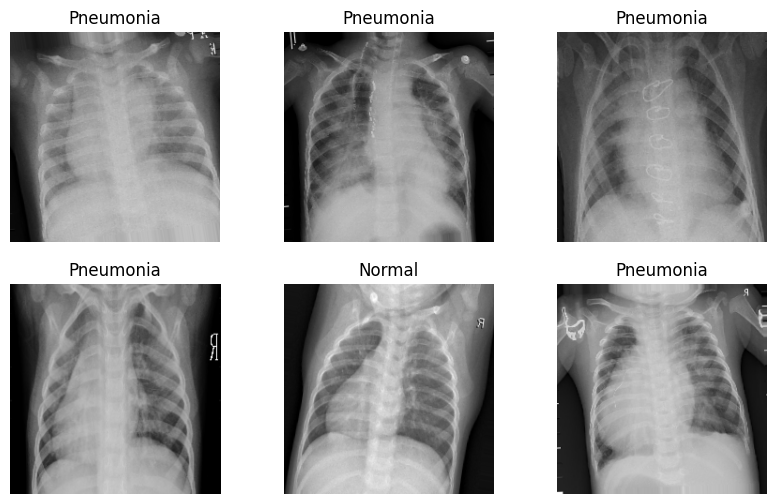

In [5]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Pneumonia" if labels[i] == 1 else "Normal")
    plt.axis("off")

plt.show()

In [6]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 413s 3s/step - accuracy: 0.8286 - loss: 0.4161 - val_accuracy: 0.7500 - val_loss: 0.5477
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 408s 3s/step - accuracy: 0.9185 - loss: 0.2075 - val_accuracy: 0.7500 - val_loss: 0.5578
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.9279 - loss: 0.1894 - val_accuracy: 0.8125 - val_loss: 0.5912
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 410s 3s/step - accuracy: 0.9304 - loss: 0.1817 - val_accuracy: 0.8125 - val_loss: 0.5234
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 413s 3s/step - accuracy: 0.9358 - loss: 0.1666 - val_accuracy: 0.8125 - val_loss: 0.3774


In [10]:
loss, accuracy = model.evaluate(test_generator)

print(f"Acurácia Final: {accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 726ms/step - accuracy: 0.7933 - loss: 0.4861
Acurácia Final: 0.7933


In [11]:
predictions = model.predict(test_generator)

y_pred = (predictions > 0.5).astype(int)

y_true = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 691ms/step


In [13]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Pneumonia"]
    )
)

              precision    recall  f1-score   support

      Normal       0.97      0.46      0.63       234
   Pneumonia       0.75      0.99      0.86       390

    accuracy                           0.79       624
   macro avg       0.86      0.73      0.74       624
weighted avg       0.84      0.79      0.77       624



In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[108 126]
 [  3 387]]


In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense

In [16]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
transfer_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [18]:
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3
)

Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 192s 1s/step - accuracy: 0.9275 - loss: 0.1890 - val_accuracy: 0.8750 - val_loss: 0.2701
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.9578 - loss: 0.1076 - val_accuracy: 0.7500 - val_loss: 0.8027
Epoch 3/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.9657 - loss: 0.0918 - val_accuracy: 1.0000 - val_loss: 0.1482


In [20]:
loss, accuracy = transfer_model.evaluate(test_generator)

print(f"Acurácia Transfer Learning: {accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 885ms/step - accuracy: 0.8862 - loss: 0.2884
Acurácia Transfer Learning: 0.8862


In [21]:
loss, accuracy = transfer_model.evaluate(test_generator)

print(f"Acurácia Transfer Learning: {accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8862 - loss: 0.2884
Acurácia Transfer Learning: 0.8862


In [22]:
predictions = transfer_model.predict(test_generator)

y_pred = (predictions > 0.5).astype(int)

y_true = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step


In [23]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Pneumonia"]
    )
)

              precision    recall  f1-score   support

      Normal       0.91      0.77      0.84       234
   Pneumonia       0.87      0.96      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.86      0.87       624
weighted avg       0.89      0.89      0.88       624



In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[180  54]
 [ 17 373]]
